# Ingredient Detection over Object Detection
This notebook addresses *Ingredient Detection*: an object detection task aimed at identifying ingredients from in-fridge images. To achieve this, we used the YOLOv11 object detection model.

# Google Colab Setup

If you're using Google Colab, first run this cell:

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Switch to the "Ingredient_Detection" directory (change according to your path)
%cd /content/drive/MyDrive/Intelligent_System/Ingredient_Detection

# Install dependencies from "requirements.txt" in project main folder
!pip install -r ../requirements.txt

## Import modules


In [ ]:
from ultralytics import YOLO
import torch
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os
import shutil
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold,MultilabelStratifiedShuffleSplit
import yaml
import seaborn as sns

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## So let's check the hardware

In [ ]:
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU Name: Tesla T4


In [ ]:
!nvidia-smi

Mon Jun 29 15:02:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Global variables


In [ ]:
DATASET_FOLDER =  "./datasets"
CLASSES = {
    0: 'apple',
    1: 'banana',
    2: 'beef',
    3: 'blueberries',
    4: 'bread',
    5: 'butter',
    6: 'carrot',
    7: 'cheese',
    8: 'chicken',
    9: 'chicken_breast',
    10: 'chocolate',
    11: 'corn',
    12: 'eggs',
    13: 'flour',
    14: 'goat_cheese',
    15: 'green_beans',
    16: 'ground_beef',
    17: 'ham',
    18: 'heavy_cream',
    19: 'lime',
    20: 'milk',
    21: 'mushrooms',
    22: 'onion',
    23: 'potato',
    24: 'shrimp',
    25: 'spinach',
    26: 'strawberries',
    27: 'sugar',
    28: 'sweet_potato',
    29: 'tomato'
}

# Data exploration

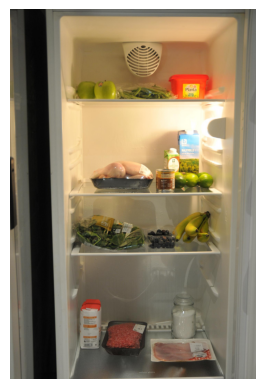

In [ ]:
path_img = DATASET_FOLDER + "/original/images/DSC_5677_JPG_jpg.rf.a8d6f2495cd383f777e9705a574f8ea8.jpg"
img = mpimg.imread(path_img)
imgSh = plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
labels_file = DATASET_FOLDER + "/original/labels/DSC_5677_JPG_jpg.rf.a8d6f2495cd383f777e9705a574f8ea8.txt"
#df = pd.DataFrame([],columns=CLASSES)
with open(labels_file) as f:
    objs = f.readlines()
print(f"Row extracted from label file:\n{objs[0]}")
print("----------------------------\n")
print("Groceries found: ")
for o in objs:
  idObject = int(o.split(" ",1)[0])
  print({CLASSES[idObject]})

Row extracted from label file:
1 0.7433286516853933 0.5911847014925373 0.1622191011235955 0.09095149253731344

----------------------------

Groceries found: 
{'banana'}
{'spinach'}
{'blueberries'}
{'flour'}
{'sugar'}
{'ground_beef'}
{'ham'}
{'butter'}
{'apple'}
{'green_beans'}
{'milk'}
{'heavy_cream'}
{'chicken'}
{'corn'}
{'lime'}


# Data exploration

In [ ]:
labels_folder = DATASET_FOLDER + "/original/labels/"
path_labels = Path(labels_folder)
records = {}
for lf in path_labels.glob("*.txt"):
    filename = lf.stem
    counter_classes =  {}
    with open(lf) as file:
      for line in file.readlines():
          spotted_class = int(line.split(" ")[0])   #retrieve the class id
          if spotted_class not in CLASSES:
              print("Class not recognized")
          if spotted_class in counter_classes:
              counter_classes[spotted_class] += 1
          else:
              counter_classes[spotted_class] = 1
    records[filename]=counter_classes
df = pd.DataFrame.from_dict(records,orient="index")
df = df.reindex(columns=CLASSES).fillna(0).astype(int)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 516 entries, DSC_5912_JPG_jpg.rf.2bdd8292f26ba5bf01f2aaf5304d5d81 to DSC_5885_JPG_jpg.rf.9b0c4be3a98e09cfe95d1f6c1f6f87aa
Data columns (total 30 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       516 non-null    int64
 1   1       516 non-null    int64
 2   2       516 non-null    int64
 3   3       516 non-null    int64
 4   4       516 non-null    int64
 5   5       516 non-null    int64
 6   6       516 non-null    int64
 7   7       516 non-null    int64
 8   8       516 non-null    int64
 9   9       516 non-null    int64
 10  10      516 non-null    int64
 11  11      516 non-null    int64
 12  12      516 non-null    int64
 13  13      516 non-null    int64
 14  14      516 non-null    int64
 15  15      516 non-null    int64
 16  16      516 non-null    int64
 17  17      516 non-null    int64
 18  18      516 non-null    int64
 19  19      516 non-null    int64
 20  20      516 non-null    i

In [ ]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
count,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,...,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000,516.000000
mean,0.356589,0.430233,0.300388,0.395349,0.284884,0.381783,0.439922,0.581395,0.430233,0.267442,...,0.503876,0.443798,0.432171,0.581395,0.463178,0.405039,0.591085,0.618217,0.389535,0.594961
std,0.522108,0.495589,0.458871,0.489400,0.451797,0.486295,0.583158,0.493809,0.495589,0.443054,...,0.672616,0.497313,0.495859,0.493809,0.499126,0.491376,0.492111,0.673765,0.555124,0.495312
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,...,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,2.000000,2.000000


In [ ]:
df.head(10)

,0,1,2,3,4,5,6,7,8,9,...,20,21,22,23,24,25,26,27,28,29
DSC_5912_JPG_jpg.rf.2bdd8292f26ba5bf01f2aaf5304d5d81,1,1,0,1,0,0,0,1,0,0,...,0,0,1,0,1,0,1,1,0,1
DSC_5740_JPG_jpg.rf.f572b9e991290730f2b860d10b92ad7a,0,1,1,0,0,0,0,0,0,0,...,0,1,1,0,0,1,1,1,0,1
DSC_5901_JPG_jpg.rf.c2dfd675bb9e2cdbf86ec199c9a749ba,0,1,1,0,0,0,0,1,1,0,...,0,0,1,0,1,0,1,0,0,1
DSC_5743_JPG_jpg.rf.e183656e98bba440377ef84c867133bd,1,1,0,0,0,0,0,0,0,0,...,0,1,1,0,1,0,1,1,0,0
DSC_5732_JPG_jpg.rf.5030f32fbbd7df1b6a04ce65f333d2f0,1,1,0,1,0,0,1,0,0,0,...,0,1,1,1,0,0,1,0,0,1
DSC_5693_JPG_jpg.rf.3a060c89a7e7509f5393c86c795c5960,0,1,0,1,0,1,0,0,0,0,...,1,0,1,1,0,0,0,2,1,1
DSC_5797_JPG_jpg.rf.90014eb325ce99effdf7fa6fc675adc8,1,1,0,1,0,1,2,0,1,0,...,2,1,1,1,0,1,1,2,1,1
DSC_5808_JPG_jpg.rf.c9329743cfd5145149e609a9418d654d,1,1,0,0,0,1,1,1,1,0,...,2,1,1,0,1,1,0,1,0,1
DSC_5821_JPG_jpg.rf.f756d4bc858480bceb4f803efde6ff2a,0,1,0,1,0,1,2,1,1,0,...,0,0,1,0,1,0,0,1,0,0
DSC_5784_JPG_jpg.rf.47542ad46adb9865b476428a9425dbfa,0,1,0,0,0,1,0,1,0,0,...,0,0,1,1,1,0,1,0,1,1


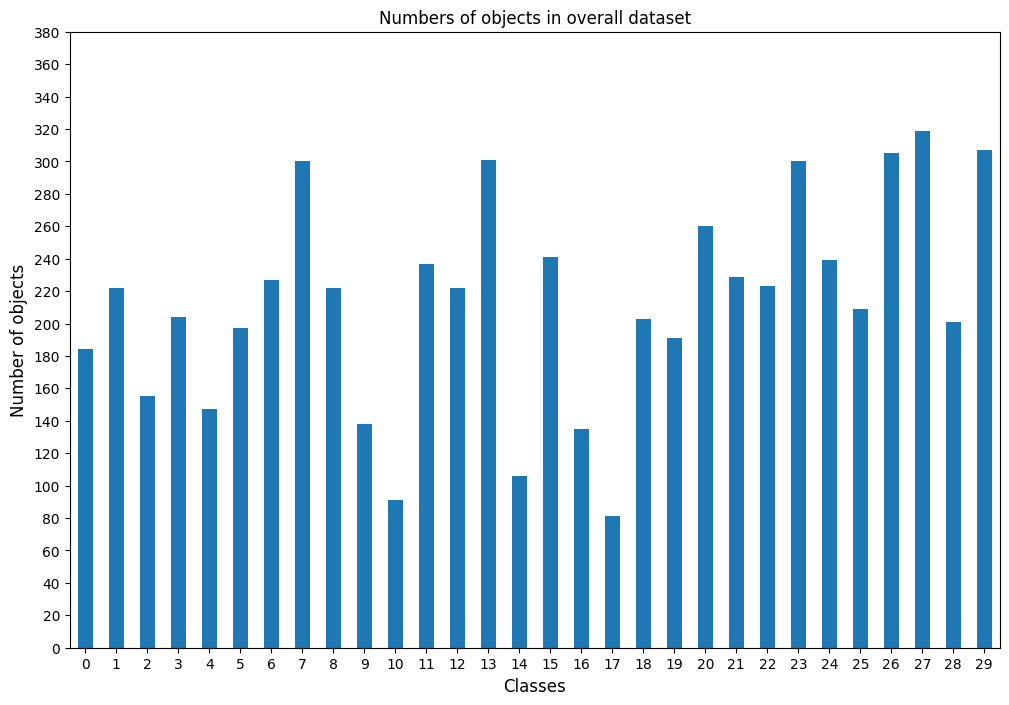

In [ ]:
# plot and histogram for retrieving counting for features
per_class_sum = df[CLASSES.keys()].sum()
plt.figure(figsize=(12,8))
per_class_sum.plot(kind='bar')
plt.title("Numbers of objects in overall dataset")
plt.ylabel("Number of objects", fontsize=12)
plt.xlabel("Classes", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(np.arange(0,400,20))
plt.show()

## YOLO v11 input requirements
Yolov11 computer vision model requires input images that has to be 640x640 pixels, but in our dataset this is not the usual case, so it is mandatory to adjust the size of images before working with the model.

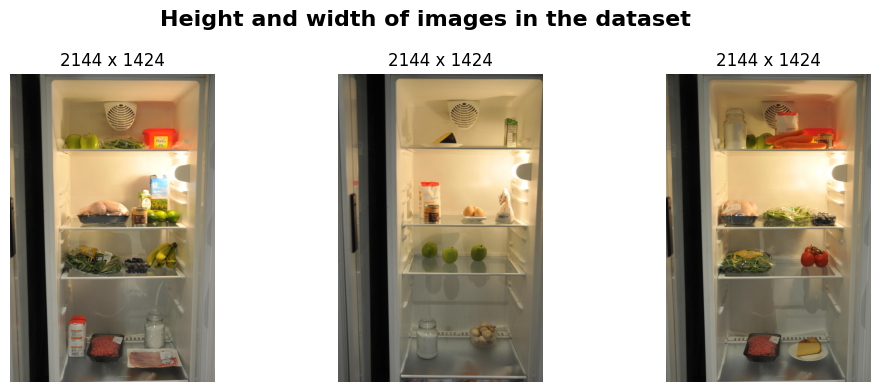

In [ ]:
path_img1 = DATASET_FOLDER + "/original/images/DSC_5677_JPG_jpg.rf.a8d6f2495cd383f777e9705a574f8ea8.jpg"
path_img2 = DATASET_FOLDER + "/original/images/DSC_6183_JPG_jpg.rf.c7f820d9824dbd06a6f46ebe53d18d7d.jpg"
path_img3 = DATASET_FOLDER + "/original/images/DSC_5679_JPG_jpg.rf.08b37c54b5772c1713a41e2b2e526a18.jpg"
paths = [path_img1, path_img2, path_img3]
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
plt.suptitle("Height and width of images in the dataset", fontsize=16, fontweight='bold', y=1.04)
for ax,i in zip(axs,paths):
  img = mpimg.imread(i)
  imgSh = ax.imshow(img)
  ax.axis('off')
  height,width,_=img.shape
  ax.set_title(f"{height} x {width}")
plt.show()

## Multiple instances of same class
In addition of what has been said before, images could contain also several objects of same class into the fridge

##

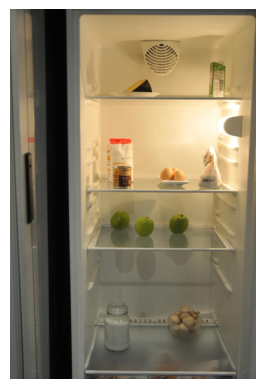

label extracted from the dataframe:

apple -> 3
banana -> 0
beef -> 0
blueberries -> 0
bread -> 0
butter -> 0
carrot -> 0
cheese -> 1
chicken -> 0
chicken_breast -> 0
chocolate -> 0
corn -> 1
eggs -> 1
flour -> 1
goat_cheese -> 0
green_beans -> 0
ground_beef -> 0
ham -> 0
heavy_cream -> 1
lime -> 0
milk -> 0
mushrooms -> 1
onion -> 0
potato -> 0
shrimp -> 0
spinach -> 0
strawberries -> 0
sugar -> 2
sweet_potato -> 0
tomato -> 0


In [ ]:
path_img = DATASET_FOLDER + "/original/images/DSC_6183_JPG_jpg.rf.c7f820d9824dbd06a6f46ebe53d18d7d.jpg"
img = mpimg.imread(path_img)
imgSh = plt.imshow(img)
plt.axis('off')
plt.show()
print("label extracted from the dataframe:\n")
counts = {CLASSES[r] : c for r,c in zip(CLASSES,df.loc['DSC_6183_JPG_jpg.rf.c7f820d9824dbd06a6f46ebe53d18d7d'])}
for i in counts:
  print( i + " -> " + str(counts[i]))


# Errare humanum est
Dataset contains some pictures that can't be adopted for YOLO, due to presence of obstacles, which avoid to spot correctly groceries. So it is necessary to delete some files from the dataset (image and labels associated).
One example is DSC_5688_JPG_jpg.rf.77e7b28bee189bc33e964717a106c9ce (image) reported below

DSC_5963_JPG_jpg.rf.bbe55fde868e234b43403d715c8ca6d0

DSC_6112_JPG_jpg.rf.6986d0a1a8b2b32742e079cb3c1926ee

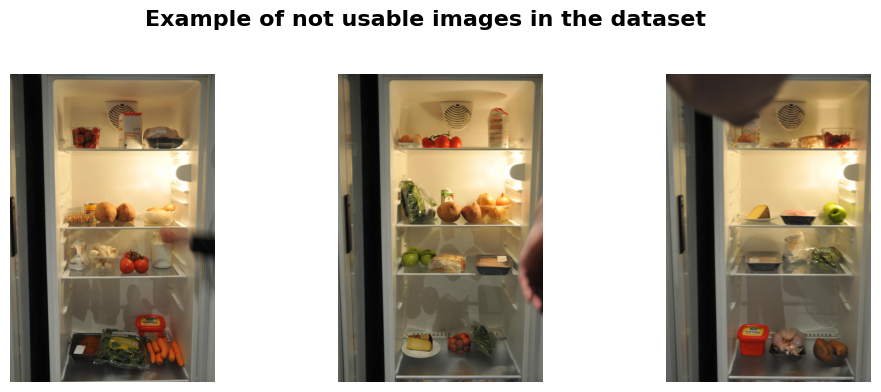

In [ ]:
path_img1 = DATASET_FOLDER + "/original/images/DSC_5688_JPG_jpg.rf.77e7b28bee189bc33e964717a106c9ce.jpg"
path_img2 = DATASET_FOLDER + "/original/images/DSC_5963_JPG_jpg.rf.bbe55fde868e234b43403d715c8ca6d0.jpg"
path_img3 = DATASET_FOLDER + "/original/images/DSC_6112_JPG_jpg.rf.6986d0a1a8b2b32742e079cb3c1926ee.jpg"
paths = [path_img1, path_img2, path_img3]
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(12, 4))
plt.suptitle("Example of not usable images in the dataset", fontsize=16, fontweight='bold', y=1.04)
for ax,i in zip(axs,paths):
  img = mpimg.imread(i)
  imgSh = ax.imshow(img)
  ax.axis('off')
  height,width,_=img.shape
plt.show()

# Refined dataset adoption
Once dataset has been cleaned, then we could use it for our models

In [ ]:
labels_folder = DATASET_FOLDER + "/refined/labels/"
path_labels = Path(labels_folder)
records = {}
for lf in path_labels.glob("*.txt"):
    filename = lf.stem
    counter_classes =  {}
    with open(lf) as file:
      for line in file.readlines():
          spotted_class = int(line.split(" ")[0])   #retrieve the class id
          if spotted_class not in CLASSES:
              print("Class not recognized")
          if spotted_class in counter_classes:
              counter_classes[spotted_class] += 1
          else:
              counter_classes[spotted_class] = 1
    records[filename]=counter_classes
df_ref = pd.DataFrame.from_dict(records,orient="index")
df_ref = df_ref.reindex(columns=CLASSES).fillna(0).astype(int)


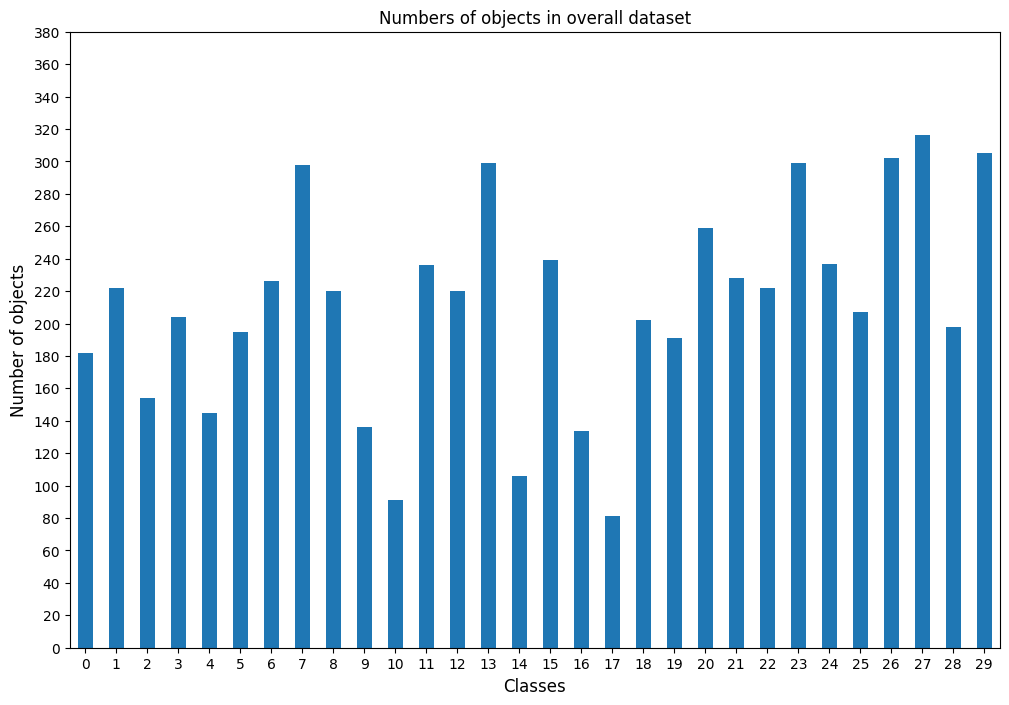

In [ ]:
per_class_sum = df_ref[CLASSES.keys()].sum()
plt.figure(figsize=(12,8))
per_class_sum.plot(kind='bar')
plt.title("Numbers of objects in overall dataset")
plt.ylabel("Number of objects", fontsize=12)
plt.xlabel("Classes", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(np.arange(0,400,20))
plt.show()

# YOLO training
We have to perform multi-label cross validation. First of all we have to setup all the directories to perform YOLO training, which requires some yaml files for each configuration we're adopting. So let's setup all stuff:

In [ ]:
# retrieve filename from the dataset
imgs = df_ref.index.to_numpy()
lbls = df_ref.to_numpy()

In [ ]:
PATH_OUTPUT_FOLDS ="./training/dataset_kfold"
# decide ho wmany cross validation run you have to perform by setting K
K = 5
rs = 42

mskf = MultilabelStratifiedKFold(n_splits=K, shuffle=True, random_state=rs)

for iter, (train_idx, val_idx) in enumerate(mskf.split(imgs, lbls)):

    # current fold directory
    fold_dir = os.path.join(PATH_OUTPUT_FOLDS, f"iter_{iter}")

    # YAML strucutre which specifies training set, validation set and classes
    # of course for each training and validation set we need to consider both images and labels
    subdirs = [
        "train/images", "train/labels",
        "val/images", "val/labels"
    ]
    for subdir in subdirs:
        os.makedirs(os.path.join(fold_dir, subdir), exist_ok=True)


    def cpfilecontents(indexes, dest):
        for idx in indexes:
            f = imgs[idx]
            new_img_file = f+ ".jpg"
            new_label_file = f + '.txt'

            # starting copying images
            src_img = os.path.join(DATASET_FOLDER, "refined","images", new_img_file)
            dst_img = os.path.join(fold_dir, dest,"images", new_img_file)
            if os.path.exists(src_img):
                shutil.copy(src_img, dst_img)

            #then labels too
            src_lbl = os.path.join(DATASET_FOLDER, "refined","labels", new_label_file)
            dst_lbl = os.path.join(fold_dir, dest, "labels", new_label_file)
            if os.path.exists(src_lbl):
                shutil.copy(src_lbl, dst_lbl)

    cpfilecontents(train_idx, "train")
    cpfilecontents(val_idx, "val")

    data_config = {
        'path': os.path.join("./dataset_kfold", f"iter_{iter}"),
        'train': 'train/images',
        'val' : 'val/images',
        'names': CLASSES
    }

    # write yaml content into a file inserted in the data fold directory ( of the current fold)
    with open(os.path.join(PATH_OUTPUT_FOLDS,f"iter_{iter}", f"data_iter_{iter}.yaml"), 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)

In [ ]:
!ls

datasets		    runs      validation  yolo11s.pt
Ingredient_detection.ipynb  training  yolo11n.pt


In [ ]:
# Switch to training folder just for this cell and run train_models.py
!cd training && python3 train_models.py

Starting training for yolo11n
Ultralytics 8.4.78 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Intelligent_System/training/dataset_kfold/iter_0/data_iter_0.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_sc

# Evaluation of the models
In order to pick the best model we will perform valuation to retrieve mAP50 metric of each class: each metric will be computed doing a mean in each of the K iteration of K-fold Cross Validation, then mean values of mAP50 for each class will be reported to choice appropriate model

In [ ]:
!pwd

/content/drive/MyDrive/Intelligent_System


Ultralytics 8.4.80 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,588,002 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 11.1±22.1 ms, read: 0.1±0.1 MB/s, size: 35.7 KB)
val: Scanning /content/drive/MyDrive/Intelligent_System/training/dataset_kfold/iter_0/val/labels.cache... 101 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 101/101 16.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.8s/it 3.6s
                   all        101       1273      0.987      0.985      0.988      0.738
                 apple         35         36      0.988      0.972      0.993      0.736
                banana         46         46          1      0.987      0.995       0.79
                  beef         32         32          1      0.948      0.988      0.651
           blueberries         40         40      0.993          1      0.995      0.69

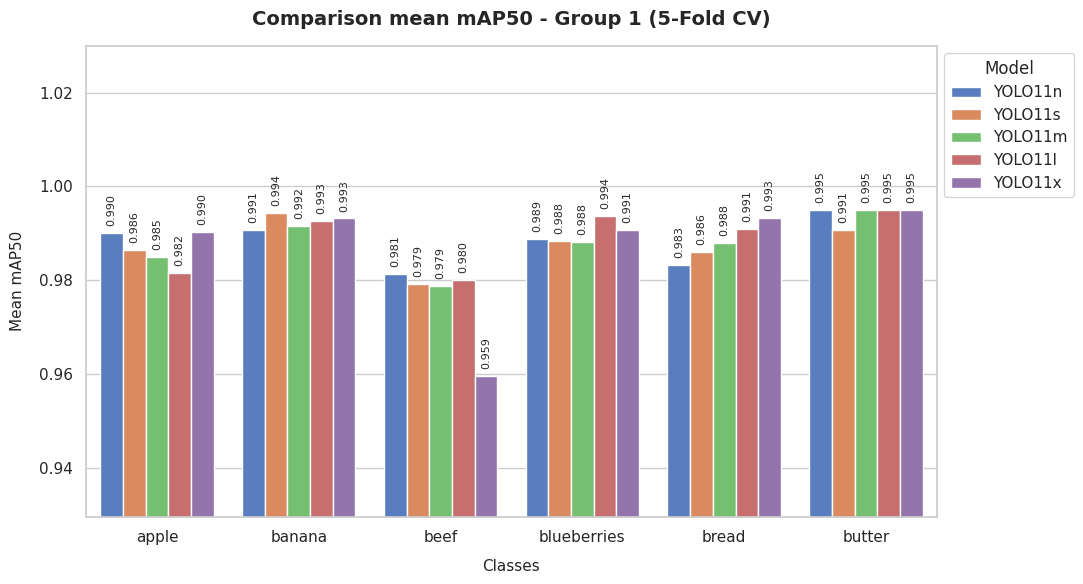

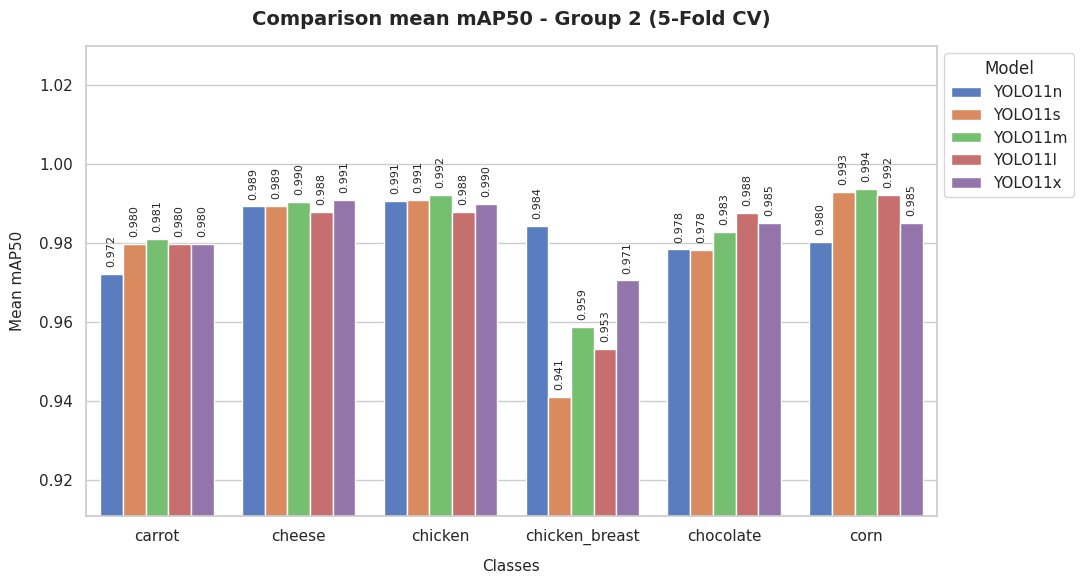

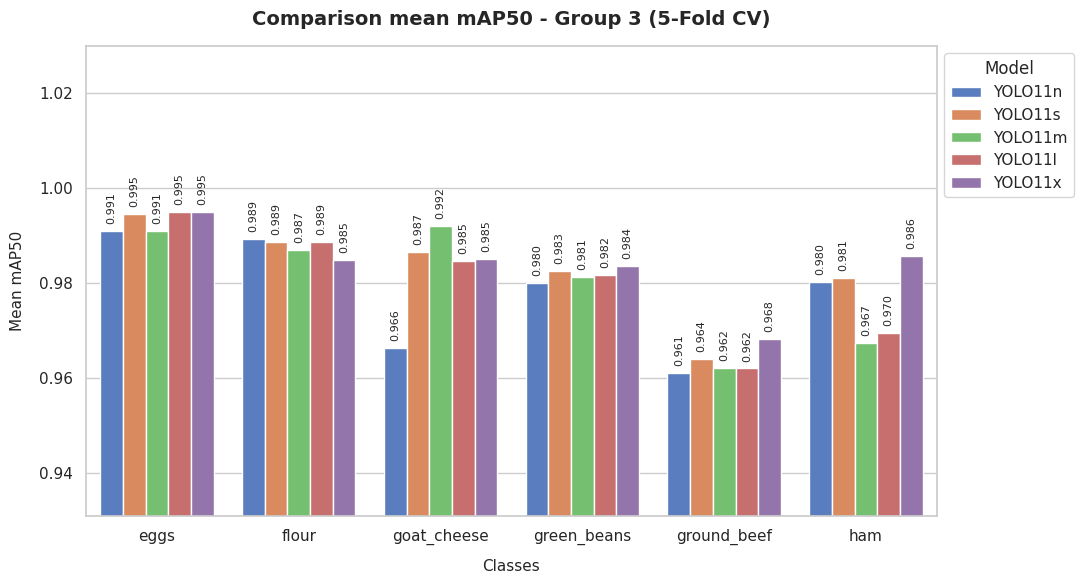

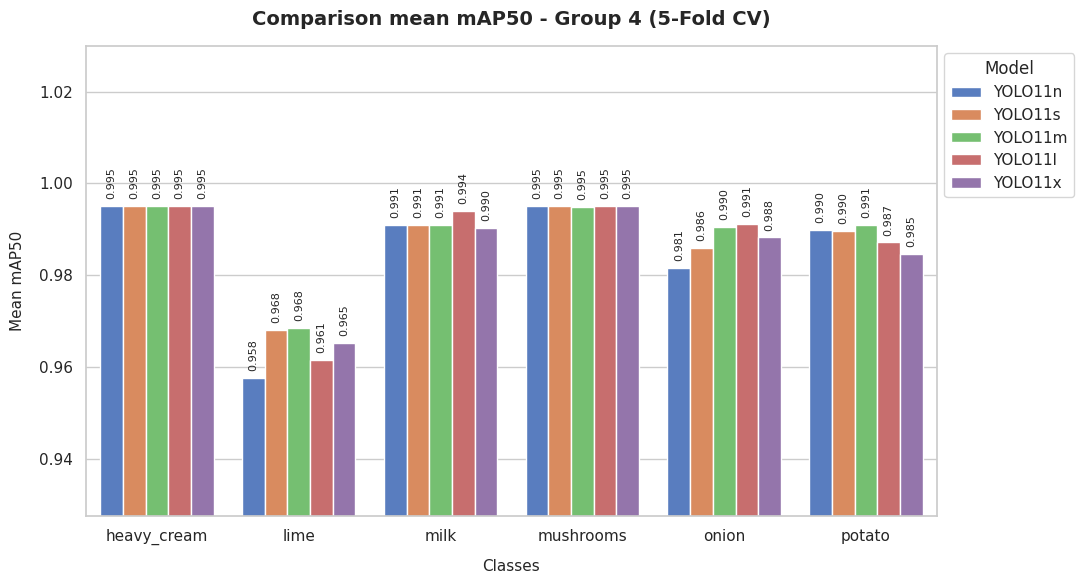

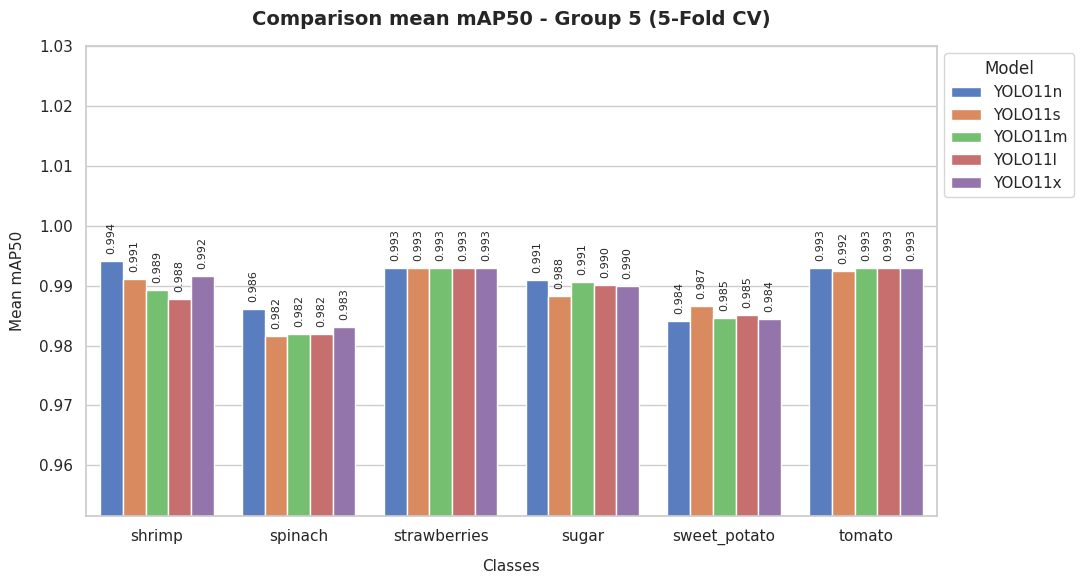

In [ ]:

models_batches = [
  ("n",64),
  ("s",32),
  ("m",16),
  ("l",8),
  ("x",4)
]
mAP50_models = list()
NUM_FOLDS = 5
score_metric = [0 for _ in models_batches]
# n, s, m, l, x
best_iteration_model = [-1 for _ in models_batches]
current_dir = Path.cwd()

for idxm,(m,b) in enumerate(models_batches):
  map50_scores_model = list()
  model_res_dir = current_dir / "training" / "res" / f"model_{m}"
  model_ds_dir = current_dir / "training" / "dataset_kfold"
  metrics_classes = [list() for _ in CLASSES.keys()]
  for i in range(0,NUM_FOLDS):
    # Take best weights for the iteration and create YOLO
    bw_file =  model_res_dir / f"iter_{i}" / "weights" / "best.pt"
    config_file = model_ds_dir / f"iter_{i}" / f"data_iter_{i}.yaml"
    # Do evaluation of the model
    model = YOLO(str(bw_file), task = "detect")
    metrics = model.val(
        data = str(config_file),
        batch = b,
        plots = False
    )

    # Extract mAP50 for each class

    for idc,cl in CLASSES.items():
      metrics_classes[idc].append(metrics.box.ap50[idc])

    map50_scores_model.append(metrics.box.map50)

  best_iteration_model[idxm] = np.argmax(map50_scores_model)

  avg_mAP50 = [np.mean(metrics_classes[idc]) for idc in CLASSES.keys()]

  mAP50_models.append(avg_mAP50)

for idx_c in CLASSES.keys():
  avg_values_per_model = [mAP50_models[idx][idx_c] for idx,(m,b) in enumerate(models_batches)]
  avg_mAP50_class= np.mean(avg_values_per_model)

  for i in range(0,len(score_metric)):
    if avg_values_per_model[i] >= avg_mAP50_class:
      score_metric[i] +=1
    else:
      score_metric[i]-=1


# then plot them

# Build the global dataframe
plot_data = []
for idx_m, (m, b) in enumerate(models_batches):
    for idc, class_name in CLASSES.items():
        plot_data.append({
            "Model": f"YOLO11{m}",
            "Class": class_name,
            "Mean mAP50": mAP50_models[idx_m][idc]
        })

df_plot = pd.DataFrame(plot_data)

# Get the list of all class names in the correct order
class_names = list(CLASSES.values())
class_per_plot = 6

# Generate 5 different plots, each one with 6 different classes
for i in range(NUM_FOLDS):
    # Select the block of 6 classes for this specific plot
    start_idx = i * class_per_plot
    end_idx = start_idx + class_per_plot
    class_blocks = class_names[start_idx:end_idx]

    # Filter the DataFrame taking only the rows of these 6 classes
    df_chunk = df_plot[df_plot["Class"].isin(class_blocks)]

    # Slightly increase the height to 6 to make room for vertical numbers
    plt.figure(figsize=(11, 6))
    sns.set_theme(style="whitegrid")

    ax = sns.barplot(
        x="Class",
        y="Mean mAP50",
        hue="Model",
        data=df_chunk,
        palette="muted"
    )

    # Find the minimum mAP50 value in this block of 6 classes
    min_val = df_chunk["Mean mAP50"].min()
    # Set the base of the Y axis leaving a margin of 0.03 (3%) below the minimum
    y_bottom = max(0.0, min_val - 0.03)
    # We go up to 1.02/1.03 so the text labels on top aren't cut off
    plt.ylim(y_bottom, 1.03)

    # Add values above the bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.3f',
            rotation=90,
            padding=5,
            fontsize=8
        )

    plt.title(f"Comparison mean mAP50 - Group {i+1} (5-Fold CV)", fontsize=14, weight="bold", pad=15)
    plt.xlabel("Classes", fontsize=11, labelpad=10)
    plt.ylabel("Mean mAP50", fontsize=11, labelpad=10)

    # Move the legend externally to the right to avoid covering the bars
    plt.legend(title="Model", loc="upper left", bbox_to_anchor=(1, 1))

    plt.tight_layout()

    # Save the file in the validation folder
    plt.savefig(f"validation/plot_class_{i+1}.png", dpi=300)

    # Show the plot
    plt.show()

    # Chiude la figura corrente per liberare la memoria
    plt.close()


# Score metrics list
the below computed list of many elements as the models and is done in order to observe how mAP50 metrics for each class retrieved for each models are, in fact if the value of mean mAP50 for a class (calculated by considering all models) is lower then the score of respective model takes +1 and -1 instead

In [ ]:

score_metric = [0 for _ in score_metric]

In [ ]:
for idx_c in CLASSES.keys():
  avg_values_per_model = [mAP50_models[idx][idx_c] for idx,(m,b) in enumerate(models_batches)]
  avg_mAP50_class= np.mean(avg_values_per_model)

  for i in range(0,len(score_metric)):
    if avg_values_per_model[i] >= avg_mAP50_class:
      score_metric[i] +=1
    else:
      score_metric[i]-=1
score_metric

[0, 6, 0, 8, 14]

For this simple analysis better model could be xlarge, but if we would like to do a trade-off with model dimensions then it could be reasonable to take large model instead, losing some precision but having lighter setup requirements

In [ ]:
# suppose to take YOLO11l
# we have to select best weights for our model and we could select the iteration that gives you the best mAP50
# n:0, s:1, m:2, l:3, x:4
best_iter = best_iteration_model[3]
# use this file to instatiate best model
best_bw_file =  current_dir / "training" / "res" / "model_l" / f"iter_{best_iter}" / "weights" / "best.pt"



PosixPath('/content/drive/MyDrive/Intelligent_System/training/res/model_x/iter_3/weights/best.pt')

# Evaluation of the single best model
Here it is reported the code to test what are effective metrics of the best model with the best weights of best iteration

In [ ]:
best_model_batch = ("l",8)
mAP50_classes = [list() for _ in CLASSES.keys()]
current_dir = Path.cwd()
best_iteration_model = 3
model_res_dir = current_dir / "training" / "res" / f"model_{best_model_batch[0]}"
model_ds_dir = current_dir / "training" / "dataset_kfold"
# Take best weights for the iteration and create YOLO
bw_file =  model_res_dir / f"iter_{best_iteration_model}" / "weights" / "best.pt"
config_file = model_ds_dir / f"iter_{best_iteration_model}" / f"data_iter_{best_iteration_model}.yaml"
# Do evaluation of the model
model = YOLO(str(bw_file), task = "detect")
metrics = model.val(
        data = str(config_file),
        batch = best_model_batch[1],
        plots = False
)
for idc,cl in CLASSES.items():
    mAP50_classes[idc]=metrics.box.ap50[idc]

# DO NOT EXECUTE THIS CELL, IT REMOVES ALL CONTENT IN KFOLD DIRECTORY

In [ ]:
if os.path.exists(PATH_OUTPUT_FOLDS):
    # Elenca tutto ciò che si trova dentro la cartella
    contenuto = os.listdir(PATH_OUTPUT_FOLDS)

    if contenuto:
        for elemento in contenuto:
            percorso_completo = os.path.join(PATH_OUTPUT_FOLDS, elemento)
            try:
                if os.path.isdir(percorso_completo):
                    shutil.rmtree(percorso_completo)  # Cancella le cartelle (es. fold_0, fold_1...)
                else:
                    os.remove(percorso_completo)      # Cancella i file (es. i file .yaml)
            except Exception as e:
                print(f"⚠️ Impossibile eliminare {elemento}: {e}")

        print(f"🧹 Il contenuto di {PATH_OUTPUT_FOLDS} è stato rimosso. La cartella ora è vuota!")
    else:
        print("ℹ️ La cartella è già vuota.")
else:
    print("ℹ️ La cartella non esiste, la creo vuota così lo script è pronto.")
    os.makedirs(PATH_OUTPUT_FOLDS, exist_ok=True)

In [ ]:
RES_DIR = "/training/res"
if os.path.exists(RES_DIR):
    # Elenca tutto ciò che si trova dentro la cartella
    contenuto = os.listdir(RES_DIR)

    if contenuto:
        for elemento in contenuto:
            percorso_completo = os.path.join(RES_DIR, elemento)
            try:
                if os.path.isdir(percorso_completo):
                    shutil.rmtree(percorso_completo)  # Cancella le cartelle (es. fold_0, fold_1...)
                else:
                    os.remove(percorso_completo)      # Cancella i file (es. i file .yaml)
            except Exception as e:
                print(f"⚠️ Impossibile eliminare {elemento}: {e}")

        print(f"🧹 Il contenuto di {RES_DIR} è stato rimosso. La cartella ora è vuota!")
    else:
        print("ℹ️ La cartella è già vuota.")
else:
    print("ℹ️ La cartella non esiste, la creo vuota così lo script è pronto.")
    os.makedirs(RES_DIR, exist_ok=True)

# BACKUP (do not execute the following cells)

From "preliminaries"

In [ ]:
!pip list > grep torch

In [ ]:
!pip install -U ultralytics

In [ ]:
!pip install iterative-stratification

From "import modules"

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip freeze > requirements.txt

In [ ]:
!python --version

Python 3.12.13


In [ ]:
!pip list

Package                                  Version
---------------------------------------- ------------------
absl-py                                  1.4.0
accelerate                               1.14.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.2
aiohttp                                  3.14.1
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.12.0
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                          